# Rain or Pumps? Attributing India's Groundwater Decline District by District

Week 1: data exploration, preparation and feature engineering

Sivakumar Kakara, BITS Pilani PGCP AI/ML Capstone

**Objective:** build a model of the expected groundwater level per district given rainfall history alone, and treat the gap between expected and observed levels as a proxy for extraction pressure.

**Data:**
1. CGWB quality-controlled groundwater levels 2000-2022, 2759 wells with specific yield (figshare, doi:10.6084/m9.figshare.29293877.v3, CC BY 4.0)
2. IMD 0.25 degree gridded daily rainfall, 1998-2022 (imdpune.gov.in). 1998-99 are only used to compute lag features for the year 2000.

Background notes before touching the data. Recharge is dominated by the June-September monsoon; secondary sources (canal seepage, irrigation return flow) are not observed in our data. Consumption is dominated by irrigation and is also not observed, which is why the project uses a residual based design. Rainfall varies a lot from year to year and from place to place, and pumping tends to increase in exactly the years when recharge falls. So the plan is: put everything rainfall driven into the baseline model, and read the remaining systematic gap as extraction pressure.

## 1. Setup

In [1]:
import os, glob, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
RNG = 42

DATA   = Path('../data')
CGWB   = DATA / 'cgwb' / 'CGWB_India_filtered_GWLs_ref_sy_2000_2022.csv'
IMDDIR = DATA / 'imd_rainfall'
PROC   = DATA / 'processed'
PROC.mkdir(parents=True, exist_ok=True)
print('CGWB exists:', CGWB.exists(), '| IMD files:', len(list(IMDDIR.glob('imd_rf25_*.nc'))))

CGWB exists: True | IMD files: 25


## 2. Data loading and rainfall extraction

The CGWB file has one row per well with seasonal reading columns (Jan/May/Aug/Nov campaigns, 2000-2022). The IMD files are yearly NetCDF grids of daily rainfall.

Each well is snapped to its nearest 0.25 degree grid node and daily rainfall at those 1547 cells is aggregated to monthly totals plus wet day counts. This avoids matching district names between two datasets. The extraction takes a few minutes, so it is skipped when the parquet output already exists.

In [2]:
RAIN_PARQUET = PROC / 'cell_monthly_rain_1998_2022.parquet'

wells_raw = pd.read_csv(CGWB)
wells_raw['well_id'] = np.arange(len(wells_raw))

def snap(v, origin, step=0.25):
    return np.round((v - origin) / step) * step + origin

wells_raw['grid_lat'] = snap(wells_raw['Latitude'], 6.5)
wells_raw['grid_lon'] = snap(wells_raw['Longitude'], 66.5)
wells_raw['cell_id']  = wells_raw['grid_lat'].astype(str) + '_' + wells_raw['grid_lon'].astype(str)

if not RAIN_PARQUET.exists():
    import xarray as xr
    cells = wells_raw[['grid_lat', 'grid_lon', 'cell_id']].drop_duplicates().reset_index(drop=True)
    lat_i = xr.DataArray(cells['grid_lat'].values, dims='cell')
    lon_i = xr.DataArray(cells['grid_lon'].values, dims='cell')
    frames = []
    for f in sorted(IMDDIR.glob('imd_rf25_*.nc')):
        ds = xr.open_dataset(f)
        da = ds['RAINFALL'].sel(LATITUDE=lat_i, LONGITUDE=lon_i, method='nearest')
        monthly = da.resample(TIME='1MS').sum(skipna=True).to_pandas()
        wetdays = (da > 2.5).resample(TIME='1MS').sum().to_pandas()   # IMD rainy day threshold
        monthly.columns = cells['cell_id']; wetdays.columns = cells['cell_id']
        m = monthly.stack().rename('rain_mm').reset_index()
        w = wetdays.stack().rename('wet_days').reset_index()
        frames.append(m.merge(w, on=['TIME', 'cell_id']))
        ds.close()
    rain_cm = pd.concat(frames, ignore_index=True).rename(columns={'TIME': 'month'})
    rain_cm.to_parquet(RAIN_PARQUET, index=False)

rain_cm = pd.read_parquet(RAIN_PARQUET)
rain_cm['month'] = pd.to_datetime(rain_cm['month'])
print(f'cell-month rainfall: {rain_cm.shape[0]:,} rows ({rain_cm.cell_id.nunique()} cells x {rain_cm.month.nunique()} months)')

cell-month rainfall: 464,100 rows (1547 cells x 300 months)


## 3. Data exploration

In [3]:
print('shape:', wells_raw.shape)
season_cols = [c for c in wells_raw.columns if c[:3] in ('Jan','May','Aug','Nov') and '-' in c]
print(len(season_cols), 'seasonal reading columns (4 campaigns x 23 years)')
print('states:', wells_raw['State'].nunique(), '| districts:', wells_raw['District'].nunique())
print(wells_raw['Type of Well'].value_counts().to_dict())

# Station Code is stored in scientific notation upstream and collides badly.
# It cannot be used as a key, so well_id (row index) is used instead.
print('unique Station Code:', wells_raw['Station Code'].nunique(), 'for', len(wells_raw), 'wells')

shape: (2759, 117)
92 seasonal reading columns (4 campaigns x 23 years)
states: 19 | districts: 365
{'Dug well': 2580, 'Bore well': 153, 'Tube well': 25, 'Dug cum bore well': 1}
unique Station Code: 182 for 2759 wells


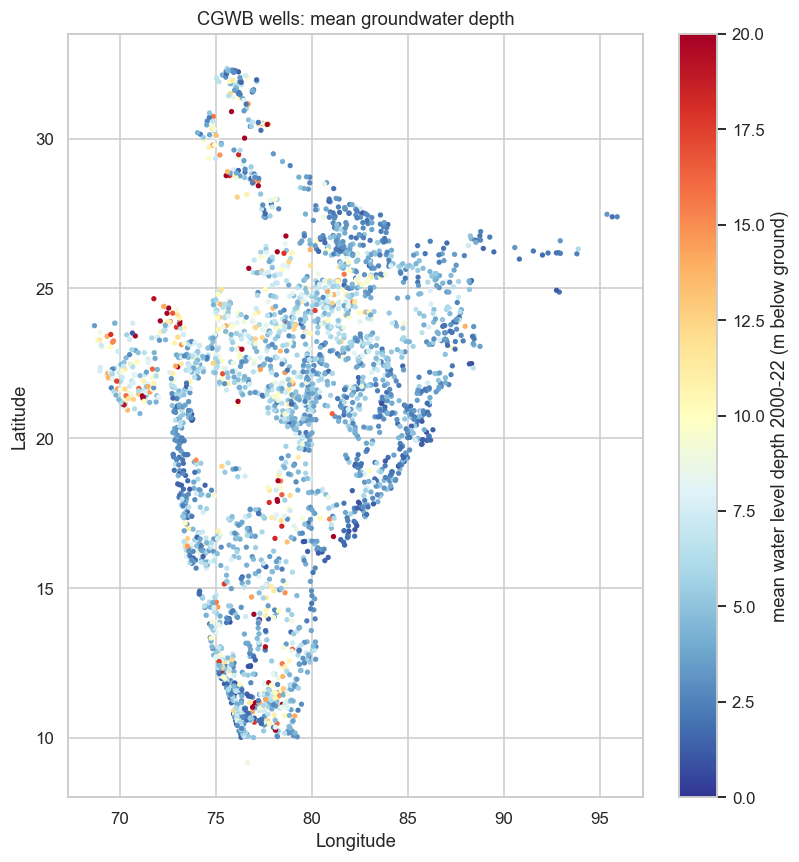

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 8))
sc = ax.scatter(wells_raw['Longitude'], wells_raw['Latitude'], s=6,
                c=wells_raw[season_cols].mean(axis=1), cmap='RdYlBu_r', vmin=0, vmax=20)
plt.colorbar(sc, label='mean water level depth 2000-22 (m below ground)')
ax.set_title('CGWB wells: mean groundwater depth')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout(); plt.show()

Deep water tables cluster in the northwest and interior peninsular districts, shallow ones along the Gangetic plain and coasts. Coverage is dense in central and south India and sparse in the northeast, so results only generalize to monitored districts. Most wells are dug wells in unconfined aquifers, which respond quickly to rainfall.

## 4. Data preparation

Melt the wide table to one row per (well, campaign, year). Target variable: `gwl_mbgl`, depth to water in meters below ground level. Larger value = deeper water table = decline.

In [5]:
idv = ['well_id','State','District','Latitude','Longitude','Type of Well','Well Depth','Reference_Sy','cell_id']
long = wells_raw.melt(id_vars=idv, value_vars=season_cols, var_name='season_col', value_name='gwl_mbgl')
mon = {'Jan':1,'May':5,'Aug':8,'Nov':11}
long['season']    = long['season_col'].str[:3]
long['month_num'] = long['season'].map(mon)
long['year']      = 2000 + long['season_col'].str[-2:].astype(int)
long['date']      = pd.to_datetime(dict(year=long['year'], month=long['month_num'], day=1))
print(f'{long.shape[0]:,} rows, observed: {long.gwl_mbgl.notna().sum():,} ({long.gwl_mbgl.notna().mean()*100:.1f}%)')
long[['well_id','State','District','season','year','gwl_mbgl']].head()

253,828 rows, observed: 219,258 (86.4%)


,well_id,State,District,season,year,gwl_mbgl
0,0,Andhra pradesh,Anantapur,Jan,2000,4.350000
1,1,Andhra pradesh,Anantapur,Jan,2000,23.879999
2,2,Andhra pradesh,Anantapur,Jan,2000,6.450000
3,3,Andhra pradesh,Anantapur,Jan,2000,9.650000
4,4,Andhra pradesh,Anantapur,Jan,2000,8.820000


## 5. Missing data analysis

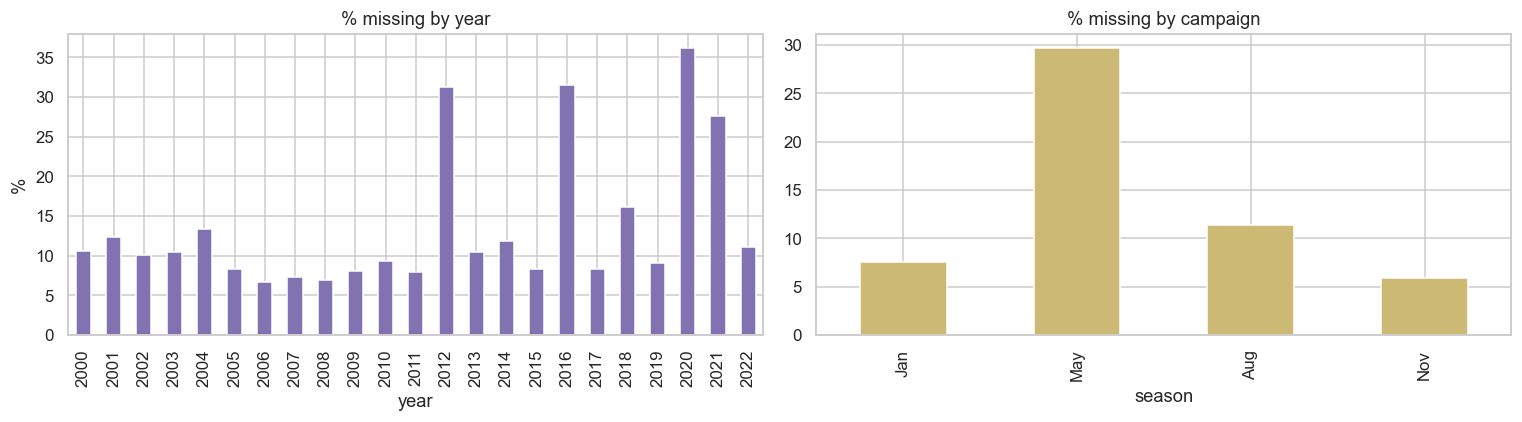

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
long.groupby('year')['gwl_mbgl'].apply(lambda s: s.isna().mean()*100).plot.bar(ax=axes[0], color='#8172b2')
axes[0].set_title('% missing by year'); axes[0].set_ylabel('%')
long.groupby('season')['gwl_mbgl'].apply(lambda s: s.isna().mean()*100).reindex(['Jan','May','Aug','Nov']).plot.bar(ax=axes[1], color='#ccb974')
axes[1].set_title('% missing by campaign')
plt.tight_layout(); plt.show()

Decisions taken:

1. May is the weakest campaign (about 30% missing, many dug wells run dry before the monsoon). 2012, 2016 and 2020-21 are weak years. All four campaigns are kept but models will be evaluated per season.
2. No imputation of the target. Imputing levels would fabricate the signal we later interpret as extraction. Missing target rows are dropped.
3. Rainfall features have no gaps since the IMD grid is complete.
4. District aggregation requires at least 3 wells per district, which keeps 272 of 365 districts.

## 6. Rainfall analysis

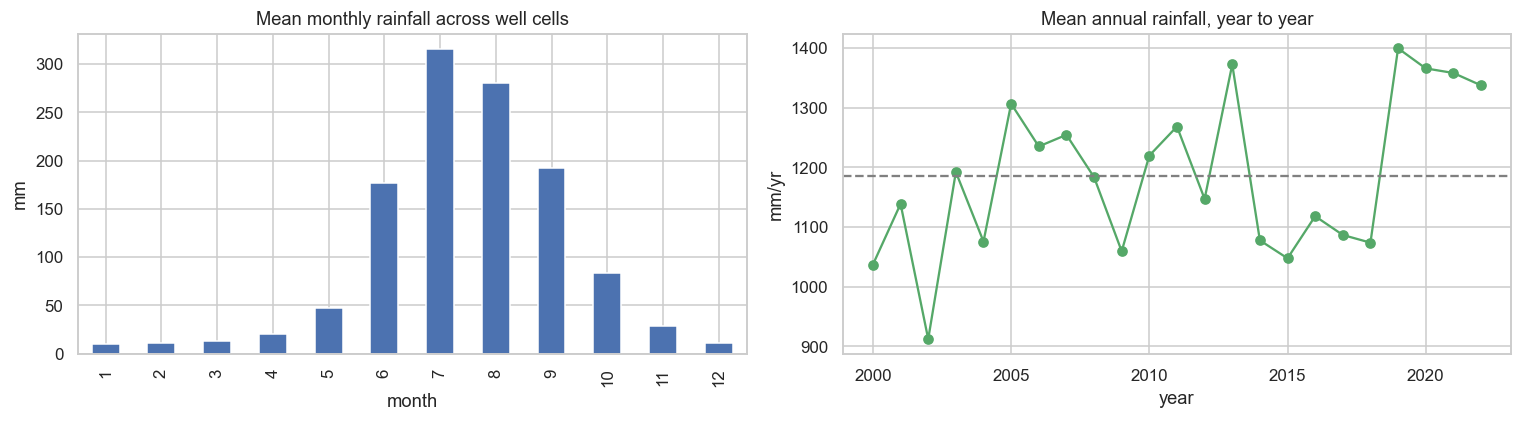

JJAS monsoon share of annual rainfall: 81.1%


In [7]:
rain_cm['cal_month'] = rain_cm['month'].dt.month
rain_cm['year'] = rain_cm['month'].dt.year
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
rain_cm.groupby('cal_month')['rain_mm'].mean().plot.bar(ax=axes[0], color='#4c72b0')
axes[0].set_title('Mean monthly rainfall across well cells'); axes[0].set_xlabel('month'); axes[0].set_ylabel('mm')
yearly = rain_cm.groupby('year')['rain_mm'].mean() * 12
yearly.loc[2000:].plot(ax=axes[1], marker='o', color='#55a868')
axes[1].axhline(yearly.loc[2000:].mean(), ls='--', c='gray')
axes[1].set_title('Mean annual rainfall, year to year'); axes[1].set_ylabel('mm/yr')
plt.tight_layout(); plt.show()
jjas_share = rain_cm[rain_cm.cal_month.isin([6,7,8,9])]['rain_mm'].sum() / rain_cm['rain_mm'].sum()
print(f'JJAS monsoon share of annual rainfall: {jjas_share*100:.1f}%')

## 7. Groundwater level analysis

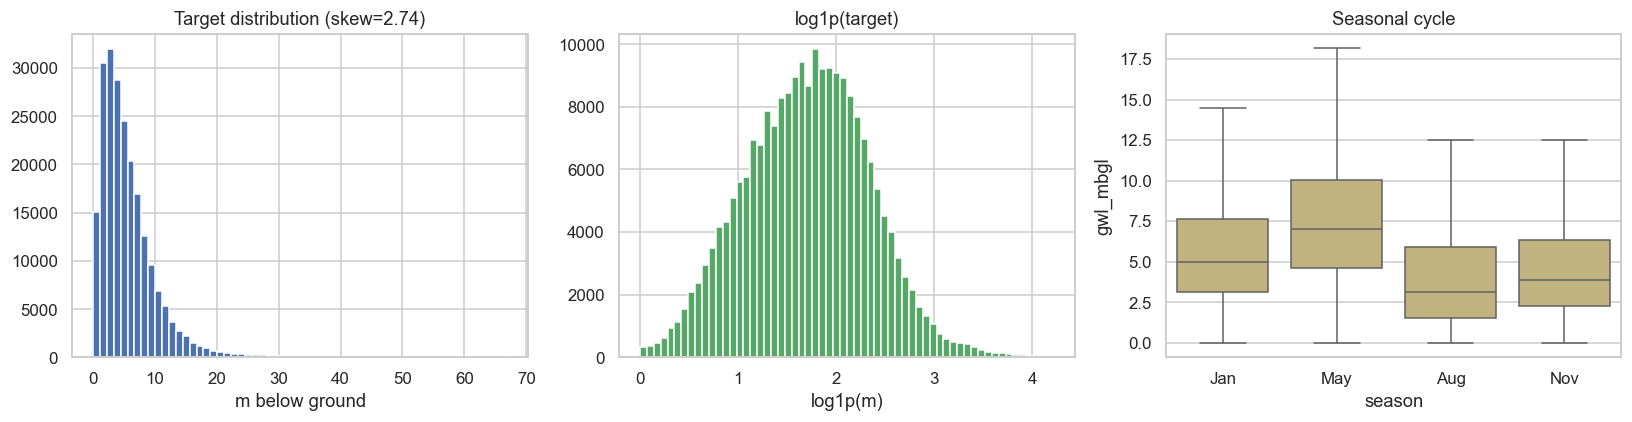

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
long['gwl_mbgl'].hist(bins=60, ax=axes[0], color='#4c72b0')
axes[0].set_title(f'Target distribution (skew={long.gwl_mbgl.skew():.2f})'); axes[0].set_xlabel('m below ground')
np.log1p(long['gwl_mbgl']).hist(bins=60, ax=axes[1], color='#55a868')
axes[1].set_title('log1p(target)'); axes[1].set_xlabel('log1p(m)')
sns.boxplot(data=long, x='season', y='gwl_mbgl', order=['Jan','May','Aug','Nov'],
            showfliers=False, ax=axes[2], color='#ccb974')
axes[2].set_title('Seasonal cycle')
plt.tight_layout(); plt.show()

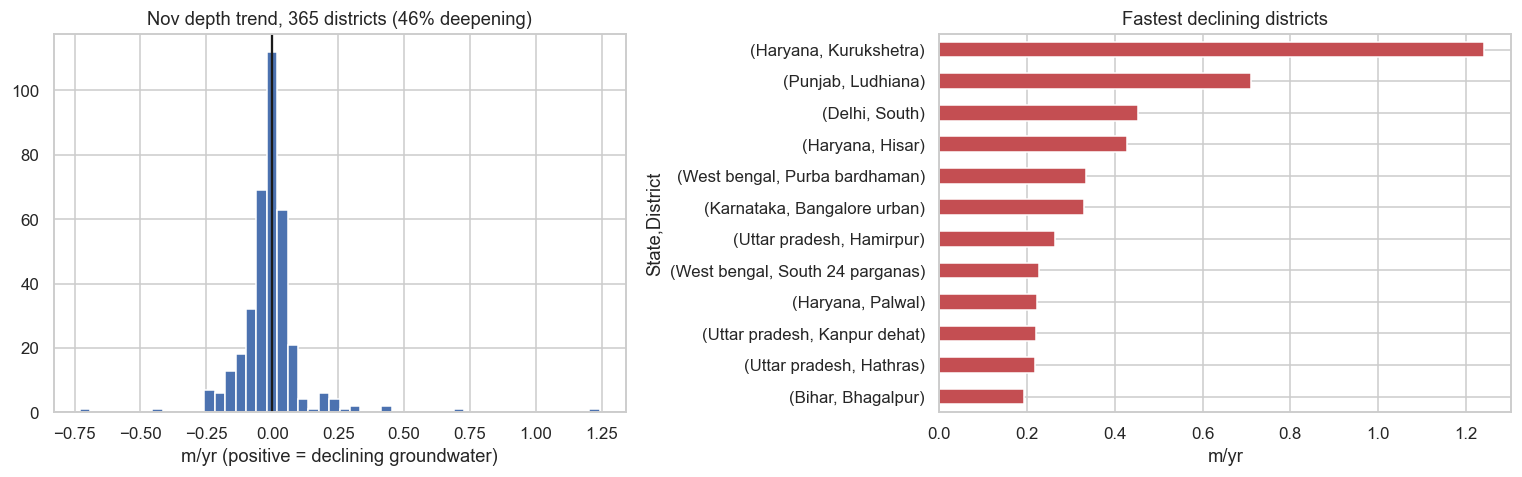

In [9]:
# linear trend of post-monsoon (Nov) depth per district
nov = long[(long.season=='Nov') & long.gwl_mbgl.notna()]
dmean = nov.groupby(['State','District','year'])['gwl_mbgl'].mean().reset_index()
def slope(g):
    return np.polyfit(g['year'], g['gwl_mbgl'], 1)[0] if len(g) >= 15 else np.nan
trend = dmean.groupby(['State','District']).apply(slope, include_groups=False).dropna().rename('slope_m_per_yr')
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
trend.hist(bins=50, ax=axes[0], color='#4c72b0'); axes[0].axvline(0, c='k')
axes[0].set_title(f'Nov depth trend, {len(trend)} districts ({(trend>0).mean()*100:.0f}% deepening)')
axes[0].set_xlabel('m/yr (positive = declining groundwater)')
trend.sort_values(ascending=False).head(12)[::-1].plot.barh(ax=axes[1], color='#c44e52')
axes[1].set_title('Fastest declining districts'); axes[1].set_xlabel('m/yr')
plt.tight_layout(); plt.show()

The target is right skewed, so models will be checked on both raw and log scales. Depth peaks in May and is shallowest in Aug, matching the monsoon cycle. About 46% of districts show a deepening post-monsoon water table. The fastest decliners (Kurukshetra, Ludhiana, Hisar, South Delhi, Bangalore Urban) are known extraction hotspots, which is a good sanity check. A raw trend alone cannot separate rain driven decline from pumping though, and that separation is the whole point of the project.

## 8. Feature engineering

All features are computable on or before the measurement date, so there is no leakage.

| Feature | Rationale |
|---|---|
| rain_3m, rain_6m | fast recharge response of shallow dug wells |
| rain_12m | full hydrological year |
| rain_24m, rain_36m | carry-over storage, multi year droughts |
| wetdays_12m | many light rain days recharge better than one cloudburst |
| rain_12m_z | anomaly vs cell climatology, separates dry place from dry year |
| last_monsoon_mm, last_monsoon_z | last completed JJAS, the main recharge pulse |
| gwl_lag1y | same season previous year, aquifer memory |
| Reference_Sy, Well Depth, lat/lon | static hydrogeological setting |

In [10]:
rain_cm = rain_cm.sort_values(['cell_id','month'])
g = rain_cm.groupby('cell_id', group_keys=False)
for w in (3, 6, 12, 24, 36):
    rain_cm[f'rain_{w}m'] = g['rain_mm'].apply(lambda s: s.rolling(w, min_periods=w).sum())
rain_cm['wetdays_12m'] = g['wet_days'].apply(lambda s: s.rolling(12, min_periods=12).sum())

clim = (rain_cm.groupby(['cell_id','cal_month'])['rain_12m'].agg(['mean','std'])
        .rename(columns={'mean':'c_mean','std':'c_std'}).reset_index())
rain_cm = rain_cm.merge(clim, on=['cell_id','cal_month'], how='left')
rain_cm['rain_12m_z'] = (rain_cm['rain_12m'] - rain_cm['c_mean']) / rain_cm['c_std'].replace(0, np.nan)

jjas = (rain_cm[rain_cm.cal_month.isin([6,7,8,9])]
        .groupby(['cell_id','year'])['rain_mm'].sum().rename('jjas_mm').reset_index())
jc = jjas.groupby('cell_id')['jjas_mm'].agg(['mean','std']).reset_index()
jjas = jjas.merge(jc, on='cell_id')
jjas['jjas_z'] = (jjas['jjas_mm'] - jjas['mean']) / jjas['std']

FEATS = ['rain_3m','rain_6m','rain_12m','rain_24m','rain_36m','wetdays_12m','rain_12m_z']
obs = long.merge(rain_cm[['cell_id','month'] + FEATS],
                 left_on=['cell_id','date'], right_on=['cell_id','month'], how='left')

# the Aug reading falls inside the ongoing monsoon, so its last completed JJAS is the previous year's
obs['monsoon_year'] = np.where(obs['month_num'].isin([1, 5, 8]), obs['year'] - 1, obs['year'])
obs = obs.merge(jjas[['cell_id','year','jjas_mm','jjas_z']]
                  .rename(columns={'year':'monsoon_year','jjas_mm':'last_monsoon_mm','jjas_z':'last_monsoon_z'}),
                on=['cell_id','monsoon_year'], how='left')

obs = obs.sort_values(['well_id','season','year'])
obs['gwl_lag1y'] = obs.groupby(['well_id','season'])['gwl_mbgl'].shift(1)
print(f'observation table: {obs.shape[0]:,} rows x {obs.shape[1]} cols')
obs[['well_id','District','season','year','gwl_mbgl','rain_12m','rain_12m_z','last_monsoon_z','gwl_lag1y']].head()

observation table: 253,828 rows x 27 cols


,well_id,District,season,year,gwl_mbgl,rain_12m,rain_12m_z,last_monsoon_z,gwl_lag1y
5518,0,Anantapur,Aug,2000,0.67,712.144094,0.005682,-1.760424,NaN
16554,0,Anantapur,Aug,2001,5.21,408.833755,-1.269821,1.022167,0.67
27590,0,Anantapur,Aug,2002,7.49,1191.476037,2.021404,1.062639,5.21
38626,0,Anantapur,Aug,2003,11.30,467.528062,-1.022995,-1.327101,7.49
49662,0,Anantapur,Aug,2004,3.69,735.461851,0.103740,-0.475176,11.30


## 9. Correlation analysis

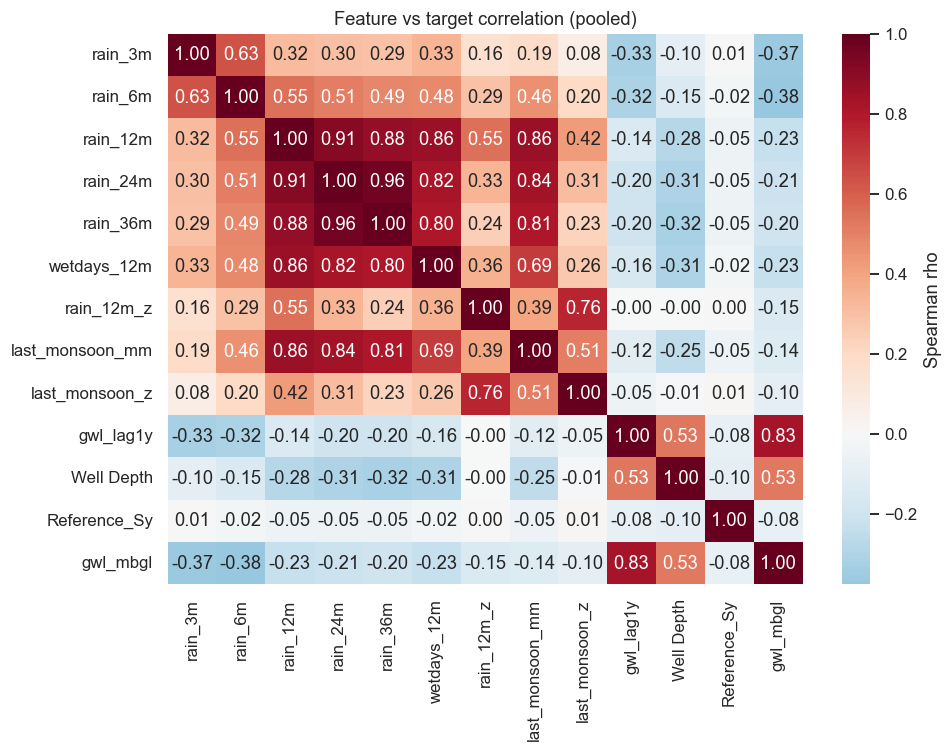

In [11]:
FEAT_ALL = FEATS + ['last_monsoon_mm','last_monsoon_z','gwl_lag1y','Well Depth','Reference_Sy']
corr = obs[FEAT_ALL + ['gwl_mbgl']].corr(method='spearman')
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'Spearman rho'})
ax.set_title('Feature vs target correlation (pooled)')
plt.tight_layout(); plt.show()

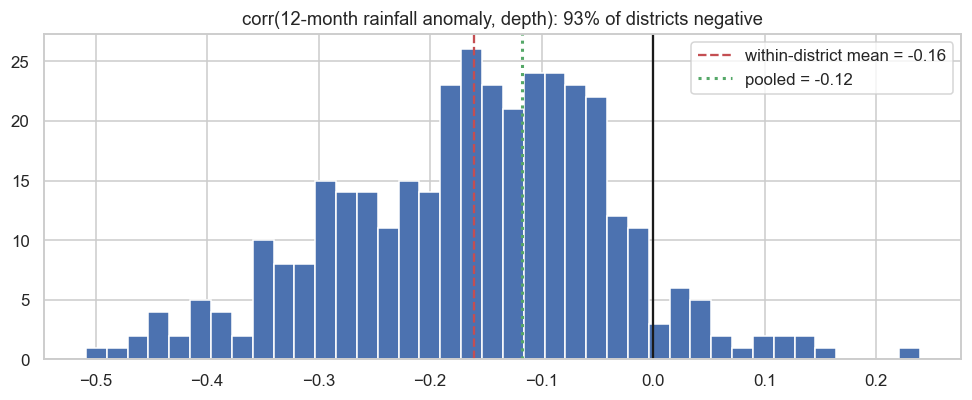

In [12]:
# pooled vs within-district correlation
d = obs.dropna(subset=['gwl_mbgl'])
pooled = d['rain_12m_z'].corr(d['gwl_mbgl'])
within = (d.groupby(['State','District'])
            .apply(lambda g: g['rain_12m_z'].corr(g['gwl_mbgl']) if len(g) > 30 else np.nan, include_groups=False)
            .dropna())
fig, ax = plt.subplots(figsize=(9, 3.8))
within.hist(bins=40, ax=ax, color='#4c72b0'); ax.axvline(0, c='k')
ax.axvline(within.mean(), c='#c44e52', ls='--', label=f'within-district mean = {within.mean():.2f}')
ax.axvline(pooled, c='#55a868', ls=':', lw=2, label=f'pooled = {pooled:.2f}')
ax.set_title(f'corr(12-month rainfall anomaly, depth): {(within<0).mean()*100:.0f}% of districts negative')
ax.legend(); plt.tight_layout(); plt.show()

Observations. Every rainfall feature correlates negatively with depth (more rain, shallower water table), strongest for the 3 to 6 month windows. `gwl_lag1y` is the strongest single predictor, so a strict rainfall-only variant of the baseline model is needed for attribution and a +lag variant for forecasting; the two answer different questions. Within-district correlations are stronger and more consistent than the pooled number because pooling mixes spatial and temporal effects, so modeling has to be district aware.

On correlation vs causation: rainfall correlating with levels does not prove the unexplained decline is pumping. Irrigation demand itself rises in dry years, canals and cropping choices confound districts, and wells sample the aquifer non randomly. The mitigation is to model the rainfall-only expectation, interpret only persistent multi-year residuals as extraction pressure, and validate the resulting ranking against CGWB stress categories that the models never see. The claim is attribution consistent with independent evidence, not proof of causation.

## 10. Feature relevance and sampling

A quick screen with mutual information and a random forest, to check the engineered features carry signal beyond linear correlation.

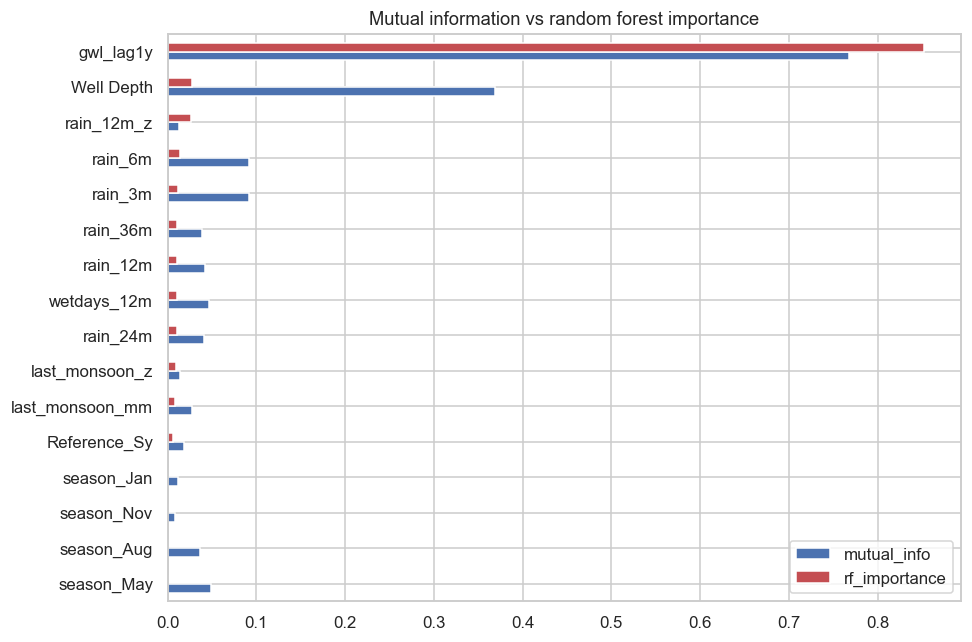

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression

Xy = obs.dropna(subset=['gwl_mbgl'] + FEAT_ALL[:-2])[FEAT_ALL + ['gwl_mbgl','season']].dropna()
X = pd.get_dummies(Xy.drop(columns='gwl_mbgl'), columns=['season'])
y = Xy['gwl_mbgl']
mi = pd.Series(mutual_info_regression(X, y, random_state=RNG, n_neighbors=5), index=X.columns)
rf = RandomForestRegressor(n_estimators=60, max_depth=14, n_jobs=-1, random_state=RNG).fit(X, y)
fi = pd.Series(rf.feature_importances_, index=X.columns)
pd.DataFrame({'mutual_info': mi, 'rf_importance': fi}).sort_values('rf_importance') \
  .plot.barh(figsize=(9, 6), color=['#4c72b0', '#c44e52'])
plt.title('Mutual information vs random forest importance')
plt.tight_layout(); plt.show()

`gwl_lag1y` dominates as expected. Among rainfall-only features the 6 to 12 month windows and the anomaly z-scores rank highest, so all windows are kept for modeling.

On over/undersampling: the regression target needs no resampling since that is a classification concept; skew is handled by evaluating on the log scale. Resampling becomes relevant in the classification validation step (predicting CGWB stress categories, which are roughly 67% safe / 15% semi-critical / 4% critical / 14% over-exploited nationally). Plan there: class weights first, SMOTE and random undersampling as comparisons, stratified splits, PR-AUC instead of accuracy.

## 11. Final data set

Two grains are saved. `well_season_obs.parquet` is the full observation table. `final_dataset_district_season.csv` is the modeling table: district x campaign for districts with at least 3 wells, target = mean depth.

In [14]:
obs.to_parquet(PROC / 'well_season_obs.parquet', index=False)

valid = obs[obs.gwl_mbgl.notna()].copy()
wpd = valid.groupby(['State','District'])['well_id'].nunique()
valid = valid.set_index(['State','District']).loc[wpd[wpd >= 3].index].reset_index()

final = (valid.groupby(['State','District','year','season','date'])
   .agg(gwl_mean=('gwl_mbgl','mean'), gwl_median=('gwl_mbgl','median'), gwl_std=('gwl_mbgl','std'),
        n_wells=('well_id','nunique'), lat=('Latitude','mean'), lon=('Longitude','mean'),
        well_depth_mean=('Well Depth','mean'), sy_mean=('Reference_Sy','mean'),
        rain_3m=('rain_3m','mean'), rain_6m=('rain_6m','mean'), rain_12m=('rain_12m','mean'),
        rain_24m=('rain_24m','mean'), rain_36m=('rain_36m','mean'),
        wetdays_12m=('wetdays_12m','mean'), rain_12m_z=('rain_12m_z','mean'),
        last_monsoon_mm=('last_monsoon_mm','mean'), last_monsoon_z=('last_monsoon_z','mean'),
        gwl_lag1y=('gwl_lag1y','mean'))
   .reset_index())
final.to_csv(PROC / 'final_dataset_district_season.csv', index=False)
print(f'final data set: {final.shape[0]:,} rows x {final.shape[1]} cols | '
      f'{final.groupby(["State","District"]).ngroups} districts | {final.year.min()}-{final.year.max()}')
final.head()

final data set: 22,715 rows x 23 cols | 272 districts | 2000-2022


,State,District,year,season,date,gwl_mean,gwl_median,gwl_std,n_wells,lat,...,rain_3m,rain_6m,rain_12m,rain_24m,rain_36m,wetdays_12m,rain_12m_z,last_monsoon_mm,last_monsoon_z,gwl_lag1y
0,Andhra pradesh,Anantapur,2000,Aug,2000-08-01,8.106923,5.915,8.068675,26,16.926531,...,447.856500,521.840344,783.697465,1416.741528,NaN,45.884615,0.315412,394.200897,-0.544789,NaN
1,Andhra pradesh,Anantapur,2000,Jan,2000-01-01,7.654231,6.505,5.174969,26,16.892000,...,18.282292,343.709747,557.961551,1338.915234,NaN,36.384615,-0.655068,391.782013,-0.539848,NaN
2,Andhra pradesh,Anantapur,2000,May,2000-05-01,9.360000,8.260,7.455407,28,16.726204,...,74.210735,104.959506,595.247481,1376.780310,NaN,37.392857,-0.470023,387.134827,-0.533807,NaN
3,Andhra pradesh,Anantapur,2000,Nov,2000-11-01,5.673571,4.670,4.017623,28,16.726204,...,165.603333,600.028388,704.987893,1261.741660,NaN,44.642857,0.058100,491.848633,0.273135,NaN
4,Andhra pradesh,Anantapur,2001,Aug,2001-08-01,8.527857,7.920,5.117760,28,16.726204,...,305.266649,379.612133,553.280490,1329.995095,1954.945986,37.535714,-0.797203,491.848633,0.273135,8.106923


## 12. LLM scope

The LLM is planned as the interface on top of the trained models, not as a model itself:

1. Natural language what-if queries, parsed by a LangGraph agent into calls to the FastAPI endpoints (/predict, /whatif, /district_rank), with answers written only from returned numbers.
2. Auto generated one page district briefs combining trend, residual ranking and peer comparison.
3. RAG over CGWB assessment reports (chunking, embeddings, retrieval) to give the agent citable district context. This is also where the text mining topic enters the project.

## 13. Conclusion

1. Both datasets are merged at the well level: 2759 wells, 253,828 observations, and a 22,715 row district-season modeling table across 272 districts (2000-2022) with full lag windows.
2. Data quality issues found and handled: Station Code is not a usable key (replaced with well_id), 13.6% of target readings missing (mostly May campaigns and 2012/2016/2020-21), no target imputation, coverage bias toward central and south India.
3. The expected physics is visible in the data: monsoon is about 79% of annual rain, depth cycles May-deep/Aug-shallow, and 96% of districts show a negative within-district rainfall to depth relationship.
4. About 46% of districts show declining post-monsoon water tables and the fastest decliners match known hotspots.
5. Feature set is defined with a no-leakage rule and screened; 6 to 12 month rainfall windows lead among rainfall features.